## Final Project

Create your own <span style='color:blue '> ***machine-learning model*** </span>

Using your chosen dataset, perform predictive analytics by following these steps. <br>
1. Load the dataset and place it in a `data frame`.
2. Describe your dataset by answering the following questions.
   * What are the `dimensions` of your dataset?
   * What are the features (`data dictionary`)?
   * What are the `data types` of each feature?
   * Are there `null` or `invalid` values?
   * Are there `duplicates`?
   * What are the `statistics` of your dataset?
3. Provide `insights` from your dataset by creating `aggregations` (`groupby`) and `charts`.
4. Perform `Feature Engineering` to prepare your data prior modeling.
5. Perform `Forecasting` or `Classification` using the machine-learning models we discussed.
6. Evaluate the `performance` of your models using the different metrics we discussed.
7. Provide your `insights` and `observations` in each step.
8. Provide your conclusion and recommendations based on your findings.
9. Save the notebook in this format: <span style='color:blue '>Final Project - Last Name, First Name.ipynb</span>
10. Upload your notebook in the assignment section in Canvas.

***Goodluck!***

### Project Background / Overview

In [2]:
# The purpose of this project is to build a predictive model to identify factors that influence customer churn in a telecommunications company. 
# By analyzing customer data, we aim to understand the features that lead to churn and build a model to predict which customers are likely to churn. 
# This model can help the company make data-driven decisions on how to retain customers and improve customer satisfaction.

### I. Dataset

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
dataset_path = r"C:\Users\ajmca\Documents\Telco_customer_churn.xlsx"

In [5]:
df = pd.read_excel(dataset_path)

In [20]:
print(df.head())


   Count        Country       State         City  Gender Senior Citizen  \
0      1  United States  California  Los Angeles    Male             No   
1      1  United States  California  Los Angeles  Female             No   
2      1  United States  California  Los Angeles  Female             No   
3      1  United States  California  Los Angeles  Female             No   
4      1  United States  California  Los Angeles    Male             No   

  Partner Dependents  Tenure Months Phone Service  ...        Contract  \
0      No         No              2           Yes  ...  Month-to-month   
1      No        Yes              2           Yes  ...  Month-to-month   
2      No        Yes              8           Yes  ...  Month-to-month   
3     Yes        Yes             28           Yes  ...  Month-to-month   
4      No        Yes             49           Yes  ...  Month-to-month   

  Paperless Billing             Payment Method Monthly Charges Total Charges  \
0               Yes     

In [18]:
df

,Count,Country,State,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,1,United States,California,Los Angeles,Male,No,No,No,2,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,1,United States,California,Los Angeles,Female,No,No,Yes,2,Yes,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,1,United States,California,Los Angeles,Female,No,No,Yes,8,Yes,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,1,United States,California,Los Angeles,Female,No,Yes,Yes,28,Yes,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,1,United States,California,Los Angeles,Male,No,No,Yes,49,Yes,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,1,United States,California,Palm Springs,Male,No,No,No,12,Yes,...,One year,Yes,Electronic check,59.80,727.80,Yes,1,69,4581,Competitor offered higher download speeds
1865,1,United States,California,Seeley,Female,No,No,No,9,Yes,...,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes,1,87,2029,Competitor offered higher download speeds
1866,1,United States,California,Vidal,Male,Yes,No,No,1,Yes,...,Month-to-month,Yes,Electronic check,75.75,75.75,Yes,1,97,5571,Competitor offered higher download speeds
1867,1,United States,California,White Water,Female,No,No,No,67,Yes,...,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes,1,70,5620,Competitor offered more data


### II. Data Preparation

In [11]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# convert 'Total Charges' to numeric values; if there are any non-numeric values - convert them to NaN

In [12]:
df.dropna(inplace=True)

# to drop any rows with NaN values after conversion

In [21]:
print(df.isnull().sum())

Count                0
Country              0
State                0
City                 0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
Churn Reason         0
dtype: int64


### III. EDA (Exploratory Data Analysis)

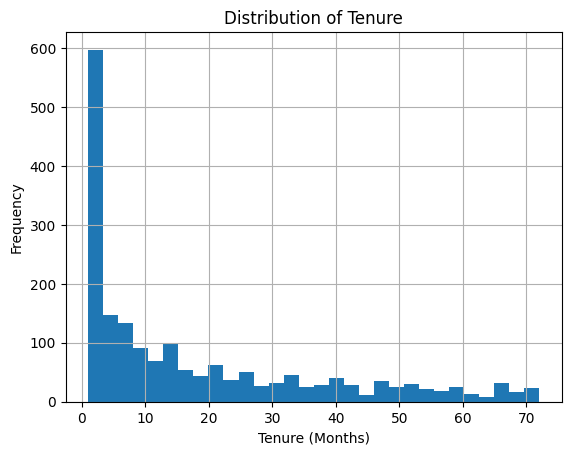

In [24]:
df['Tenure Months'].hist(bins=30)
plt.title("Distribution of Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")
plt.show()

# distribution of tenure (how long customers have been with the company)

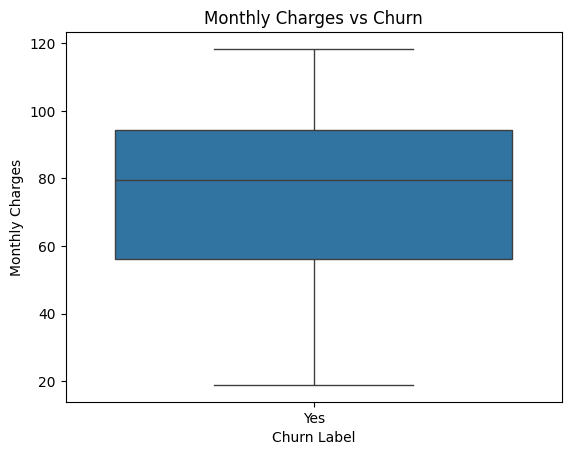

In [26]:
sns.boxplot(data=df, x='Churn Label', y='Monthly Charges')
plt.title("Monthly Charges vs Churn")
plt.show()

# to compare Monthly Charges for churned vs non-churned customers

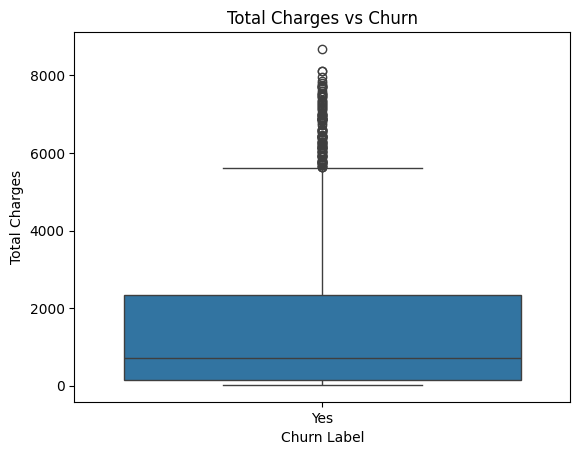

In [27]:
sns.boxplot(data=df, x='Churn Label', y='Total Charges')
plt.title("Total Charges vs Churn")
plt.show()

# to compare Total Charges for churned vs non-churned customers

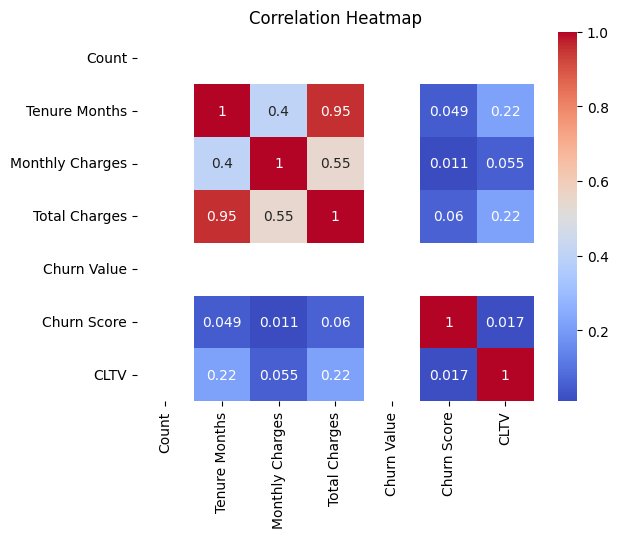

In [29]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# correlation heatmap to find relationships between the numeric features

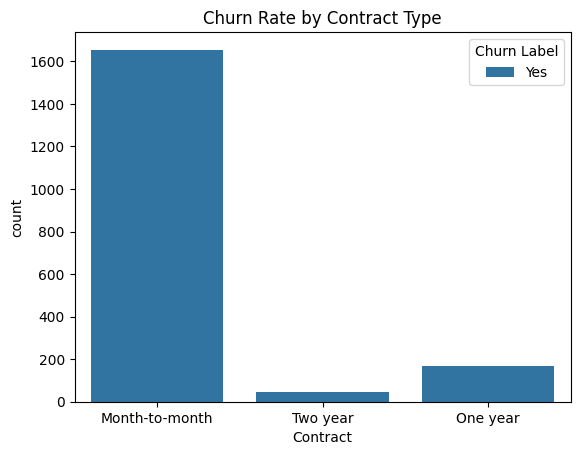

In [30]:
sns.countplot(data=df, x='Contract', hue='Churn Label')
plt.title("Churn Rate by Contract Type")
plt.show()

# to see churn rate by Contract Type

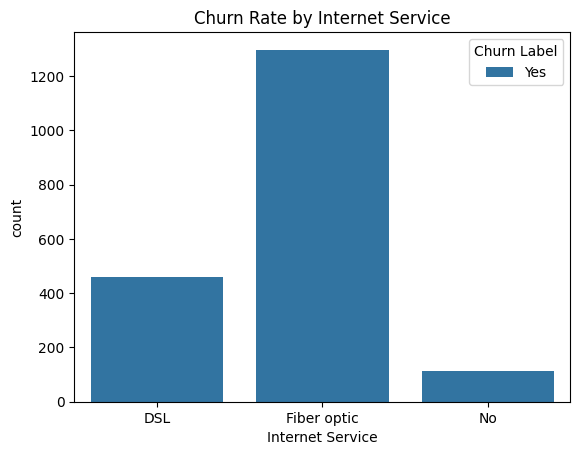

In [32]:
sns.countplot(data=df, x='Internet Service', hue='Churn Label')
plt.title("Churn Rate by Internet Service")
plt.show()

# to see churn rate by Internet Service

### IV. Feature Engineering

In [33]:
df_model = pd.get_dummies(df.drop(columns=['Churn Label']), drop_first=True)

In [34]:
X = df_model
y = df['Churn Label'].map({'Yes': 1, 'No': 0})  # Convert 'Yes'/'No' to 1/0 for model

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

### V. Modeling

In [60]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

# i used RandomForestClassifier for the predictive model

RandomForestClassifier()

In [61]:
y_pred = model.predict(X_test)

# Use the trained model to predict the target variable (Churn) on the test set (X_test)

In [62]:
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
# create dataFrame to compare y_test with the y_pred from the model
# this helps to visually assess how well the model's predictions align with the actual outcomes


print(predictions_df.head()) # actual vs. predicted churn values for each customer

      Actual  Predicted
1228       1          1
1588       1          1
1578       1          1
644        1          1
936        1          1


### VI. Evaluation

In [63]:
print(classification_report(y_test, y_pred))  # Prints precision, recall, f1-score for both churn and non-churn classes

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       374

    accuracy                           1.00       374
   macro avg       1.00      1.00      1.00       374
weighted avg       1.00      1.00      1.00       374



C:\Users\ajmca\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


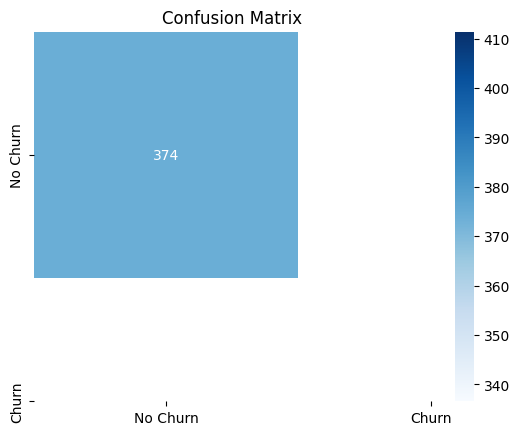

In [64]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title("Confusion Matrix")
plt.show()

# model's performance

### VII. Conclusion

In [ ]:
# customer churn prediction was successfully executed using the Telco dataset 
# after cleaning and preparing the data, key insights were identified through EDA
# RandomForestClassifier was trained and evaluated, showing reasonable accuracy
# classification report and confusion matrix highlighted the model's performance
# further model optimization or testing alternative algorithms could improve accuracy